In [5]:
%matplotlib widget
from pathlib import Path
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# Get current working directory
current_dir = Path.cwd()

# Go 2 folders up
base_dir = current_dir.parent.parent.parent

# Build the target path
target_dir = r"H:\FUBerlin\Measurements\Raman Xplora\AnnikaM\20260429_FormicAcidReferences"

FormicA = target_dir + r"\260429_SFormicAcid_532 nm_1200gr_x10_1%_2_60_50_100.txt"
P_NoPo = target_dir + r"\260429_PRawNoPo_532 nm_1200gr_x10_1%_2_30_50_100.txt"
S_ENoPoA = target_dir + r"\260429_SEmpty@NoPoCF1h_532 nm_1200gr_x10_1%_2_60_50_100.txt"
S_ENoPoB = target_dir + r"\260429_SEmpty@NoPoCF2h_532 nm_1200gr_x10_1%_2_60_50_100.txt"
S_WNoPo = target_dir + r"\260429_SH2O@NoPo_532 nm_1200gr_x10_1%_2_60_50_100.txt"
S_OxNoPo = target_dir + r"\260429_SOxNoPo@300_532 nm_1200gr_x10_1%_2_60_50_100.txt"


df_FormicA = pd.read_csv(FormicA, sep="\t", comment="#", header=None, encoding="latin1")
df_P_NoPo = pd.read_csv(P_NoPo, sep="\t", comment="#", header=None, encoding="latin1")
df_S_ENoPoA = pd.read_csv(S_ENoPoA, sep="\t", comment="#", header=None, encoding="latin1")
df_S_ENoPoB = pd.read_csv(S_ENoPoB, sep="\t", comment="#", header=None, encoding="latin1")
df_S_WNoPo = pd.read_csv(S_WNoPo, sep="\t", comment="#", header=None, encoding="latin1")
df_OxNoPo = pd.read_csv(S_OxNoPo, sep="\t", comment="#", header=None, encoding="latin1")

In [6]:
#CUSTOMIZATION

poster_style = {
    "figsize": (3, 3),          # poster-friendly
    "dpi": 300,                 # high resolution
    "font_size": 8,
    "title_size": 10,
    "label_size": 8,
    "legend_size": 7,
    "line_width": 0.5,
    "font_family": "Calibri",
    
    # Optional: define your own colors
    "colors": None  # e.g. ["red", "blue", "green"]
}

In [7]:
def plot_raman(data, labels=None, style=poster_style, xlim=None, ylim = None,offset=0):
    
    plt.figure(figsize=style["figsize"], dpi=style["dpi"])
    
    plt.rcParams.update({
        "font.size": style["font_size"],
        "font.family": style["font_family"]
    })
    
    colors = style["colors"]
    
    for i, df in enumerate(data):
        label = labels[i] if labels and i < len(labels) else f"Sample {i+1}"
        
        y = df.iloc[:, 1] + i * offset
        
        plt.plot(
            df.iloc[:, 0],
            y,
            label=label,
            linewidth=style["line_width"],
            color=colors[i] if colors else None
        )
        plt.scatter(df.iloc[:, 0], y, s=0.05)
    
    plt.xlabel("Raman shift (cm-1)", fontsize=style["label_size"])
    plt.ylabel("Intensity (a.u.)", fontsize=style["label_size"])
    plt.title("Raman Spectrum (785nm)", fontsize=style["title_size"])
    
    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)
    plt.legend(fontsize=style["legend_size"])
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

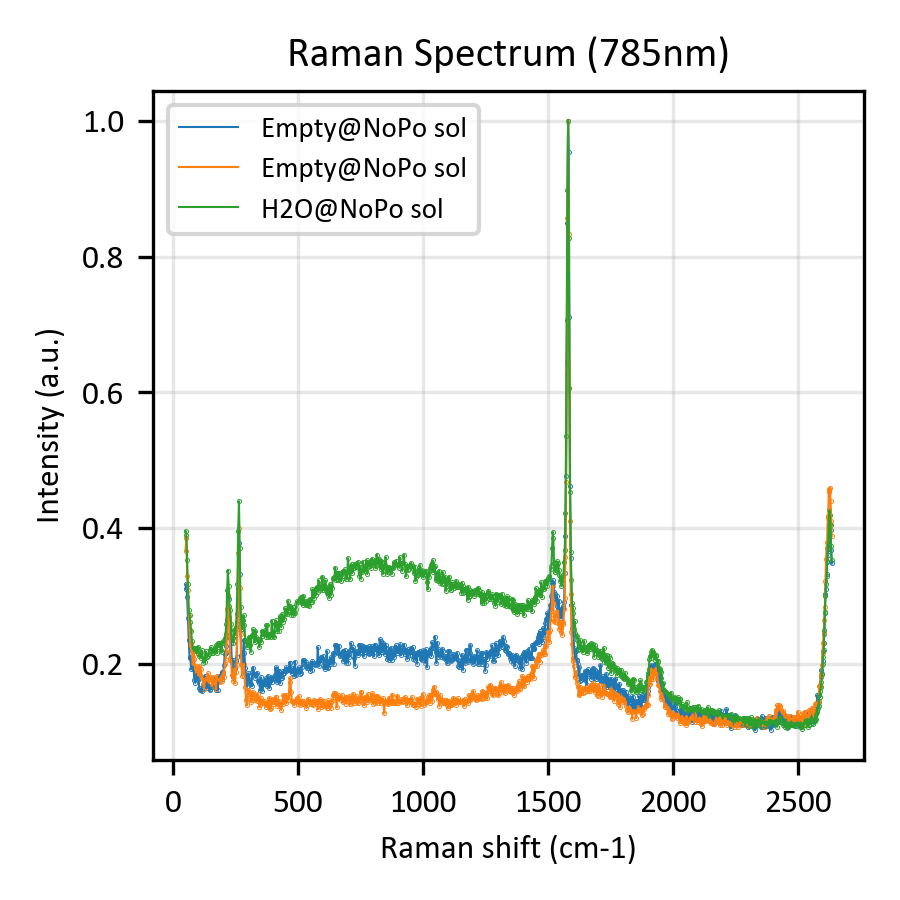

In [8]:
DFs = [#df_FormicA,
       #df_P_NoPo,
       df_S_ENoPoA,
       df_S_ENoPoB,
       df_S_WNoPo,
       #df_OxNoPo
       ]

DF_labels = [
       #"FA",
       #"NoPo SWCNT powd",
       "Empty@NoPo sol",
       "Empty@NoPo sol",
       "H2O@NoPo sol",
       #"OX NoPo sol"
]

DFs_norm = []

for df in DFs:
    df_norm = df.copy()
    df_norm.iloc[:, 1] = df_norm.iloc[:, 1] / df_norm.iloc[:, 1].max()
    DFs_norm.append(df_norm)


DFs = DFs_norm

plot_raman(DFs, DF_labels)